In [110]:
# =========================
# 1. Import Libraries
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 2. Load Dataset
# =========================
df = pd.read_csv("breast_cancer_dataset.csv")

# =========================
# 3. Quick Overview
# =========================
df.shape


(5000, 12)

In [111]:
df.head()


,Patient_ID,Age,Tumor_Size,Tumor_Type,Lymph_Node_Status,Hormone_Receptor_Status,Genetic_Mutation,Treatment,Survival_Status,Follow_Up_Duration,Blood_Pressure,BMI
0,Patient_1,58,4.253744,Benign,Positive,Unknown,BRCA2,Chemotherapy,Alive,57,164,28.887681
1,Patient_2,71,7.275465,Benign,Positive,Negative,Other,Hormone Therapy,Deceased,59,124,25.787189
2,Patient_3,48,2.392545,Malignant,Positive,Positive,Other,Surgery,Deceased,70,93,24.819432
3,Patient_4,34,8.957043,Malignant,Positive,Positive,BRCA1,Radiation,Deceased,15,174,26.278296
4,Patient_5,62,3.230391,Benign,Negative,Negative,Other,Surgery,Alive,86,101,31.455969


In [112]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               5000 non-null   str    
 1   Age                      5000 non-null   int64  
 2   Tumor_Size               5000 non-null   float64
 3   Tumor_Type               5000 non-null   str    
 4   Lymph_Node_Status        5000 non-null   str    
 5   Hormone_Receptor_Status  5000 non-null   str    
 6   Genetic_Mutation         5000 non-null   str    
 7   Treatment                5000 non-null   str    
 8   Survival_Status          5000 non-null   str    
 9   Follow_Up_Duration       5000 non-null   int64  
 10  Blood_Pressure           5000 non-null   int64  
 11  BMI                      5000 non-null   float64
dtypes: float64(2), int64(3), str(7)
memory usage: 468.9 KB


In [113]:
df.describe()

,Age,Tumor_Size,Follow_Up_Duration,Blood_Pressure,BMI
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,49.70120,5.193138,66.149800,129.419600,28.990819
std,17.26688,2.732746,31.180792,28.636298,6.344274
min,20.00000,0.500111,12.000000,80.000000,18.000122
25%,35.00000,2.830674,39.000000,105.000000,23.384936
50%,50.00000,5.141228,66.000000,130.000000,29.054604
75%,65.00000,7.545695,94.000000,154.000000,34.347367
max,79.00000,9.995798,119.000000,179.000000,39.995366


In [114]:
# =========================
# 4. Check Missing Values
# =========================
df.isnull().sum()


Patient_ID                 0
Age                        0
Tumor_Size                 0
Tumor_Type                 0
Lymph_Node_Status          0
Hormone_Receptor_Status    0
Genetic_Mutation           0
Treatment                  0
Survival_Status            0
Follow_Up_Duration         0
Blood_Pressure             0
BMI                        0
dtype: int64

In [115]:
# =========================
# 5. Remove Duplicates
# =========================
df.duplicated().sum()

np.int64(0)

Tumor_Type
Malignant    2519
Benign       2481
Name: count, dtype: int64


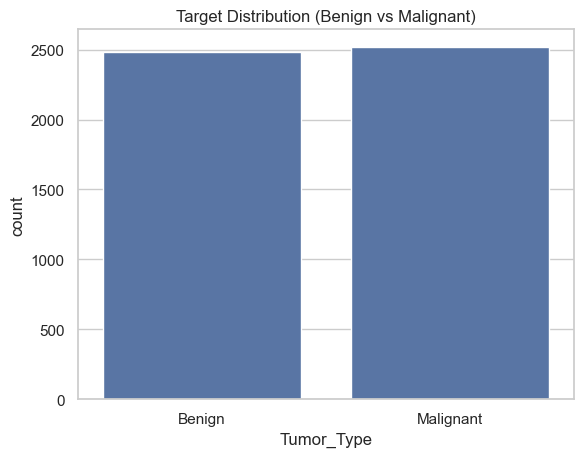

In [116]:

# =========================
# 6. Target Variable Analysis
# =========================
print(df['Tumor_Type'].value_counts())

sns.countplot(x='Tumor_Type', data=df)
plt.title("Target Distribution (Benign vs Malignant)")
plt.show()

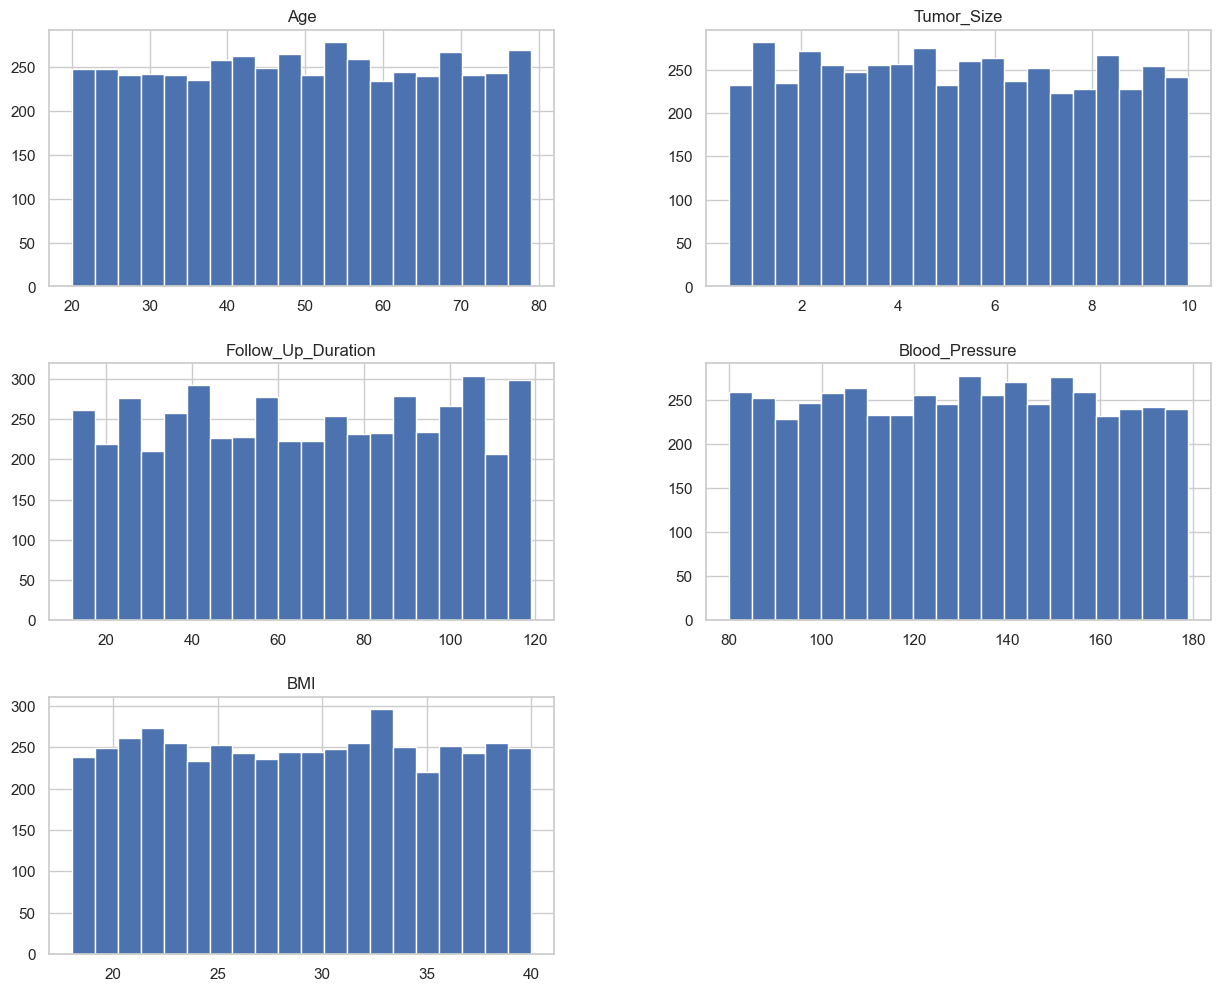

In [117]:
# =========================
# 10. Feature Distribution (optional)
# =========================
df.hist(figsize=(15,12), bins=20)
plt.show()


In [118]:
df["Genetic_Mutation"].unique()

<StringArray>
['BRCA2', 'Other', 'BRCA1']
Length: 3, dtype: str

In [119]:
df["Hormone_Receptor_Status"].unique()

<StringArray>
['Unknown', 'Negative', 'Positive']
Length: 3, dtype: str

In [120]:
df["Lymph_Node_Status"].unique()

<StringArray>
['Positive', 'Negative']
Length: 2, dtype: str

In [121]:
# =========================
# 7. Encode Target Variable
# =========================
df['Tumor_Type'] = df['Tumor_Type'].map({'Benign': 0, 'Malignant': 1})
# =========================
# 8. Drop columns 
# =========================
df = df.drop(['Patient_ID', 'Treatment', 'Survival_Status', 'Follow_Up_Duration'], axis=1)


# df = df.drop('Lymph_Node_Status', axis=1)
# df = df.drop('Hormone_Receptor_Status', axis=1)

# df = df.drop('Blood_Pressure', axis=1)
# df = df.drop('BMI', axis=1)

df = pd.get_dummies(
    df,
    columns=['Genetic_Mutation', 'Hormone_Receptor_Status', 'Lymph_Node_Status'],
    prefix=['Mutation', 'Hormone_Receptor_Status', 'Lymph_Node_Status'],
    drop_first=True
)


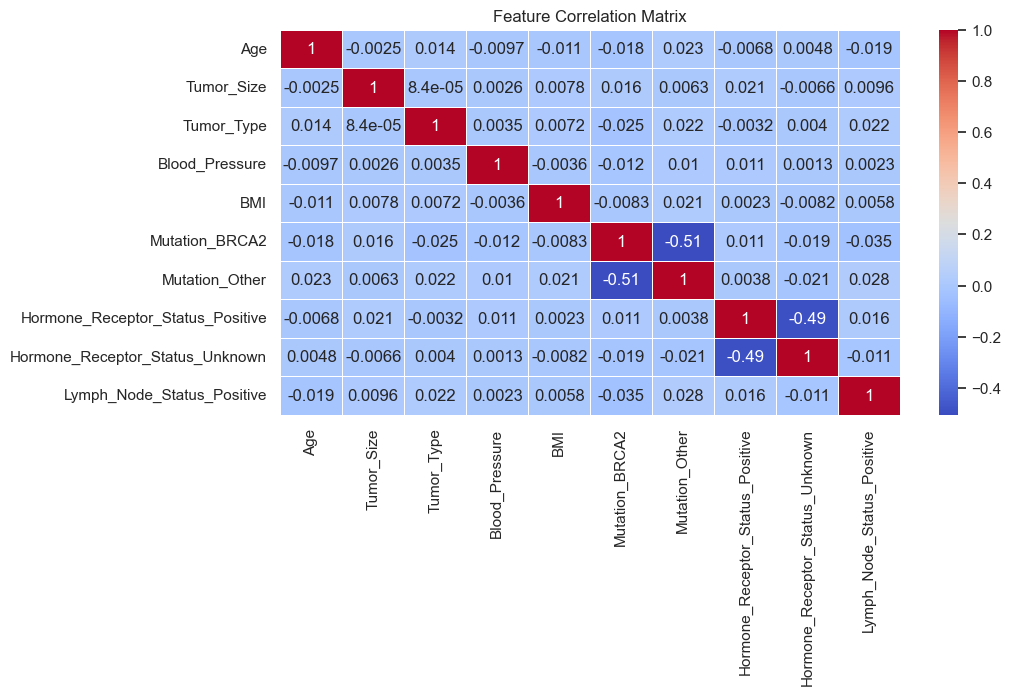

In [122]:

# =========================
# 9. Correlation Analysis
# =========================
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(), cmap="coolwarm", linewidths=0.5, annot=True)
plt.title("Feature Correlation Matrix")
plt.show()

In [123]:
# =========================
# 12. Feature Scaling
# =========================
from sklearn.preprocessing import StandardScaler

X = df.drop('Tumor_Type', axis=1)
y = df['Tumor_Type']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# =========================
# 13. Final Check
# =========================
print("Final dataset ready for model training")
print(X_scaled.head())
print(y.head())

Final dataset ready for model training
        Age  Tumor_Size  Blood_Pressure       BMI  Mutation_BRCA2  \
0  0.480668   -0.343789        1.207693 -0.016258        1.407663   
1  1.233629    0.762067       -0.189275 -0.505015       -0.710397   
2 -0.098534   -1.024930       -1.271926 -0.657570       -0.710397   
3 -0.909416    1.377472        1.556935 -0.427597       -0.710397   
4  0.712348   -0.718304       -0.992532  0.388602       -0.710397   

   Mutation_Other  Hormone_Receptor_Status_Positive  \
0       -0.711035                         -0.701493   
1        1.406401                         -0.701493   
2        1.406401                          1.425532   
3       -0.711035                          1.425532   
4        1.406401                         -0.701493   

   Hormone_Receptor_Status_Unknown  Lymph_Node_Status_Positive  
0                         1.423599                      1.0008  
1                        -0.702445                      1.0008  
2                   


--- Training SVM ---
SVM Accuracy: 0.5210
              precision    recall  f1-score   support

           0       0.52      0.43      0.47       493
           1       0.52      0.61      0.56       507

    accuracy                           0.52      1000
   macro avg       0.52      0.52      0.52      1000
weighted avg       0.52      0.52      0.52      1000


--- Training Random Forest ---
Random Forest Accuracy: 0.4910
              precision    recall  f1-score   support

           0       0.48      0.47      0.48       493
           1       0.50      0.51      0.50       507

    accuracy                           0.49      1000
   macro avg       0.49      0.49      0.49      1000
weighted avg       0.49      0.49      0.49      1000


--- Training LDA ---
LDA Accuracy: 0.4920
              precision    recall  f1-score   support

           0       0.48      0.43      0.45       493
           1       0.50      0.56      0.53       507

    accuracy                     

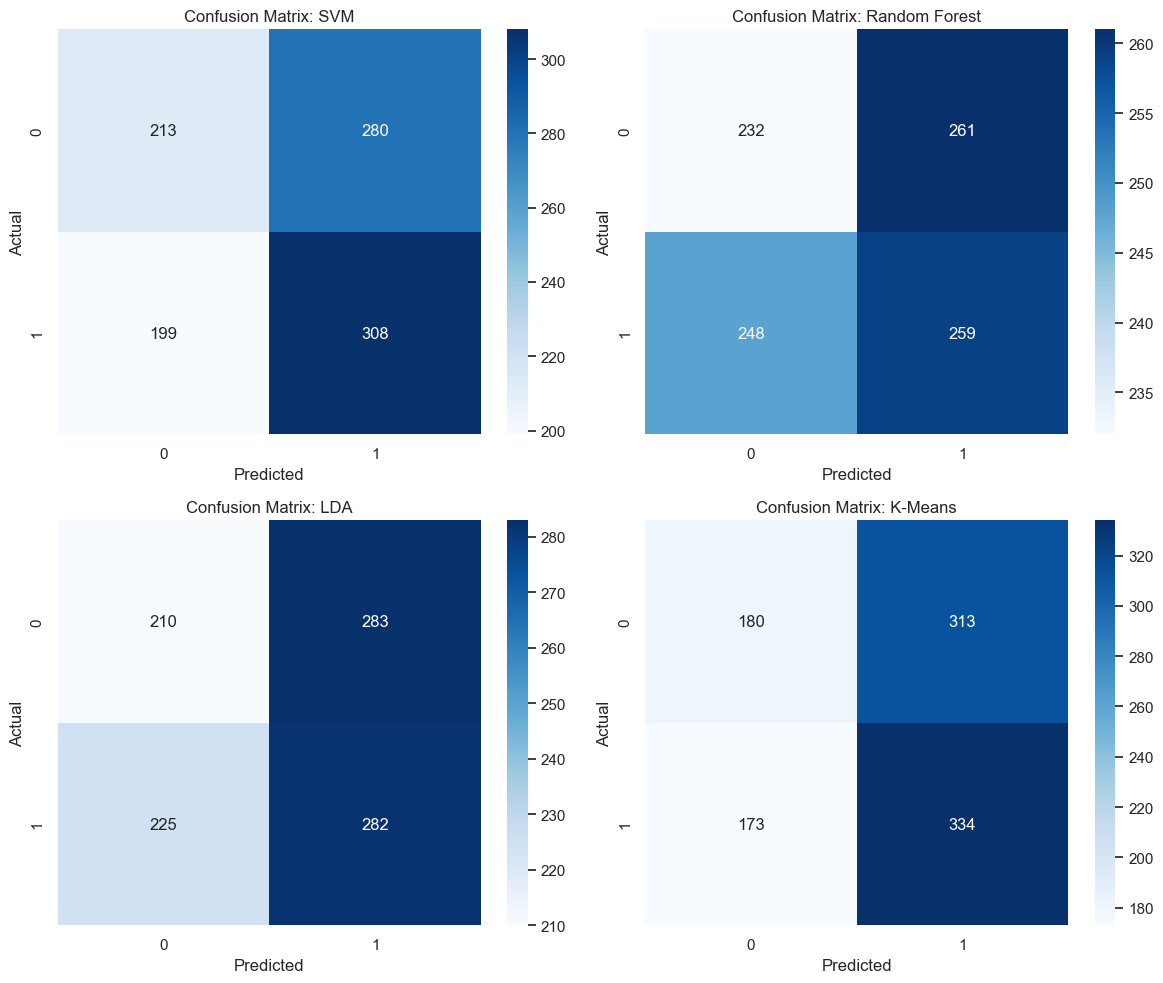

In [124]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target variable from features list if it's categorical
target_col = 'Tumor_Type'
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

# Label Encoding for categorical features
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Encode the target variable (Benign: 0, Malignant: 1)
df[target_col] = le.fit_transform(df[target_col])

# Define Features (X) and Target (y)
X = df.drop(target_col, axis=1)
y = df[target_col]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Model Training and Evaluation

results = {}

# --- SVM ---
print("\n--- Training SVM ---")
svm_model = SVC(kernel='rbf',C=10, gamma='scale', class_weight='balanced', random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
results['SVM'] = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {results['SVM']:.4f}")
print(classification_report(y_test, y_pred_svm))

# --- Random Forest ---
print("\n--- Training Random Forest ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
results['RandomForest'] = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {results['RandomForest']:.4f}")
print(classification_report(y_test, y_pred_rf))

# --- LDA ---
print("\n--- Training LDA ---")
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train_scaled, y_train)
y_pred_lda = lda_model.predict(X_test_scaled)
results['LDA'] = accuracy_score(y_test, y_pred_lda)
print(f"LDA Accuracy: {results['LDA']:.4f}")
print(classification_report(y_test, y_pred_lda))

# --- K-Means (Unsupervised) ---
print("\n--- Applying K-Means ---")
# Since we have 2 classes (Benign/Malignant), we set n_clusters=2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)
# Predict clusters for test set
clusters = kmeans.predict(X_test_scaled)

# Note: K-Means labels (0, 1) might not match our target labels (0, 1)
# We can check which cluster corresponds to which label by looking at the majority
from scipy.stats import mode
labels = np.zeros_like(clusters)
for i in range(2):
    mask = (clusters == i)
    if np.any(mask):
        labels[mask] = mode(y_test[mask])[0]

results['K-Means'] = accuracy_score(y_test, labels)
print(f"K-Means (as classifier) Accuracy: {results['K-Means']:.4f}")
print(classification_report(y_test, labels))

# 4. Summary of Results
print("\n--- Summary of Accuracies ---")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

# Visualization of Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
models_preds = [
    ('SVM', y_pred_svm),
    ('Random Forest', y_pred_rf),
    ('LDA', y_pred_lda),
    ('K-Means', labels)
]

for i, (name, pred) in enumerate(models_preds):
    ax = axes[i//2, i%2]
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix: {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()


In [107]:
from xgboost import XGBClassifier

print("\n--- Training XGBoost ---")
xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
results['XGBoost'] = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {results['XGBoost']:.4f}")
print(classification_report(y_test, y_pred_xgb))

ModuleNotFoundError: No module named 'xgboost'

In [125]:
from sklearn.ensemble import GradientBoostingClassifier

print("\n--- Training Gradient Boosting ---")
gb_model = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42)
gb_model.fit(X_train_scaled, y_train)
y_pred_gb = gb_model.predict(X_test_scaled)
results['GradientBoosting'] = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting Accuracy: {results['GradientBoosting']:.4f}")
print(classification_report(y_test, y_pred_gb))


--- Training Gradient Boosting ---
Gradient Boosting Accuracy: 0.4830
              precision    recall  f1-score   support

           0       0.47      0.44      0.46       493
           1       0.49      0.52      0.51       507

    accuracy                           0.48      1000
   macro avg       0.48      0.48      0.48      1000
weighted avg       0.48      0.48      0.48      1000



In [126]:
print("توزيع البيانات:")
print(f"Benign (0): {sum(y_train == 0)}")
print(f"Malignant (1): {sum(y_train == 1)}")

توزيع البيانات:
Benign (0): 1988
Malignant (1): 2012
